load the label file:

In [1]:
import pandas as pd

y_df = pd.read_csv('brca_survival_label_Luminal.csv')
y_df = y_df[['Case.ID', 'Slide.ID', 'survival_days', 'censor', 'survival_interval']]
y_df

,Case.ID,Slide.ID,survival_days,censor,survival_interval
0,TCGA-E2-A1IE,TCGA-E2-A1IE-01Z-00-DX1,2362,1,3.0
1,TCGA-A2-A0CP,TCGA-A2-A0CP-01Z-00-DX1,2813,1,3.0
2,TCGA-EW-A3E8,TCGA-EW-A3E8-01Z-00-DX1,1035,1,2.0
3,TCGA-A2-A0YL,TCGA-A2-A0YL-01Z-00-DX1,1474,1,2.0
4,TCGA-A1-A0SQ,TCGA-A1-A0SQ-01Z-00-DX1,554,1,1.0
...,...,...,...,...,...
422,TCGA-A7-A3RF,TCGA-A7-A3RF-01Z-00-DX1,408,1,0.0
423,TCGA-E9-A1R0,TCGA-E9-A1R0-01Z-00-DX1,860,1,2.0
424,TCGA-E2-A155,TCGA-E2-A155-01Z-00-DX1,640,1,1.0
425,TCGA-C8-A132,TCGA-C8-A132-01Z-00-DX1,383,1,0.0


**!!!Replace with your selected genes and predicted genes here!!!**

load the data file, we use the `tpm_unstranded` gene counts as features here, and select the higly 250 expressed for trianing and testing:

In [2]:
import warnings

# Filter or ignore specific warning categories
warnings.filterwarnings("ignore")
from glob import glob
from tqdm import tqdm

# load all bulk rna-seq data as a big dataframe
all_rna_file_path = glob("/data1/r20user3/shared_project/Hist2Cell/data/brca/*/*.rna_seq.augmented_star_gene_counts.tsv")
case_rna_df_list = []
for rna_file_path in tqdm(all_rna_file_path):
    case = rna_file_path.split("/")[-2]
    df = pd.read_csv(rna_file_path, sep="\t", skiprows=1, header=0)
    df = df[4:]
    brca_df = df[["gene_name", "tpm_unstranded"]]
    brca_df["gene_name"] = brca_df["gene_name"].str.split('.', expand=True)[0]
    brca_df = brca_df.drop_duplicates(subset=["gene_name"])
    new_brca_df = pd.DataFrame(columns=brca_df['gene_name'].values, data=[brca_df['tpm_unstranded'].values], index=[case])
    case_rna_df_list.append(new_brca_df)
    
all_case_rna_df = pd.concat(case_rna_df_list, join='inner')
all_case_rna_df.head(2)

100%|██████████| 826/826 [08:35<00:00,  1.60it/s]


,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CDR1,AL139190,AC119733,AC010980,AC007511,AL451106,AC073611,AC136977,AC078856,AL391628
TCGA-E2-A1IE-01Z-00-DX1,34.5847,1.1065,129.3534,14.4737,7.6050,3.9460,10.1275,46.4962,10.3253,84.8503,...,0.0,0.0202,0.0,0.0315,0.0,0.0,0.4421,0.0,0.0,0.0146
TCGA-AR-A1AT-01Z-00-DX1,28.3693,0.1866,92.0135,15.0553,8.4406,13.4883,28.8008,65.7654,10.5013,45.0618,...,0.0,0.0000,0.0,0.0928,0.0,0.0,0.0966,0.0,0.0,0.0286


In [3]:
# generate X_df accodring to index of y_df, and only keep the 250 highly expressed genes

X_all_df = all_case_rna_df.loc[y_df['Slide.ID'].values]
# Calculate the mean of each column
column_means = X_all_df.mean()
# Get the indices of the 250 columns with the largest means
largest_250_indices = column_means.nlargest(250).index
# Select only the 250 columns with the largest means
X_df = X_all_df[largest_250_indices]
X_df.head(2)

,MT-CO3,MT-CO1,MT-CO2,MT-ND4,MT-RNR2,MT-ATP6,MT-CYB,MT-ND1,MT-ND3,MT-ND2,...,SPDEF,MTND2P28,ISG15,SRP9,RPL34,EEF1B2,GJA1,CSDE1,TBC1D9,CTSZ
TCGA-E2-A1IE-01Z-00-DX1,30900.1874,29375.1747,26822.6181,22667.7304,15009.7866,14796.6468,14302.2374,12928.1309,12338.4753,12258.1969,...,496.6506,404.0426,111.4065,438.4084,379.6323,394.7836,1050.3042,517.9610,714.6850,349.6080
TCGA-A2-A0CP-01Z-00-DX1,39306.9412,24000.6251,25094.3568,33217.3106,32516.4992,19015.1475,20216.3353,27286.8311,18905.4884,15230.4312,...,364.3360,390.8223,144.2027,211.4163,720.1975,557.7114,186.7430,299.7373,133.3881,337.0016


In [ ]:
X_df.to_csv('bulk_seq_largest250_df.csv')

In [31]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()
X_df = pd.DataFrame(scaler.fit_transform(X_df), columns=X_df.columns, index=X_df.index)
X_df.head(2)

,MT-CO3,MT-CO1,MT-CO2,MT-ND4,MT-RNR2,MT-ATP6,MT-CYB,MT-ND1,MT-ND3,MT-ND2,...,SPDEF,MTND2P28,ISG15,SRP9,RPL34,EEF1B2,GJA1,CSDE1,TBC1D9,CTSZ
TCGA-E2-A1IE-01Z-00-DX1,0.287345,0.422847,0.223511,0.351643,0.103643,0.264956,0.340875,0.220612,0.247119,0.302411,...,0.307627,0.102252,0.018308,0.370472,0.168451,0.222532,0.166418,0.410323,0.332106,0.097734
TCGA-A2-A0CP-01Z-00-DX1,0.381291,0.335373,0.205414,0.543196,0.260526,0.356057,0.506881,0.519904,0.412593,0.386264,...,0.217295,0.098894,0.024018,0.125236,0.426506,0.345999,0.027980,0.210762,0.049405,0.093639


merge X_df and y_df to get dataset_df

In [32]:
y_df = y_df.set_index('Slide.ID')
y_df.head(2)

,Case.ID,survival_days,censor,survival_interval
Slide.ID,,,,
TCGA-E2-A1IE-01Z-00-DX1,TCGA-E2-A1IE,2362,1,3.0
TCGA-A2-A0CP-01Z-00-DX1,TCGA-A2-A0CP,2813,1,3.0


In [33]:
dataset_df = X_df.merge(y_df[['survival_days', 'censor', 'survival_interval']], left_index=True, right_index=True, how='outer')
dataset_df.head(2)

,MT-CO3,MT-CO1,MT-CO2,MT-ND4,MT-RNR2,MT-ATP6,MT-CYB,MT-ND1,MT-ND3,MT-ND2,...,SRP9,RPL34,EEF1B2,GJA1,CSDE1,TBC1D9,CTSZ,survival_days,censor,survival_interval
TCGA-E2-A1IE-01Z-00-DX1,0.287345,0.422847,0.223511,0.351643,0.103643,0.264956,0.340875,0.220612,0.247119,0.302411,...,0.370472,0.168451,0.222532,0.166418,0.410323,0.332106,0.097734,2362,1,3.0
TCGA-A2-A0CP-01Z-00-DX1,0.381291,0.335373,0.205414,0.543196,0.260526,0.356057,0.506881,0.519904,0.412593,0.386264,...,0.125236,0.426506,0.345999,0.027980,0.210762,0.049405,0.093639,2813,1,3.0


split dataset into 70% training and 30% testing:

In [34]:
# split the initial dataset
from sklearn.model_selection import train_test_split

x = dataset_df
y = dataset_df['survival_interval']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.7, random_state=2000)

In [35]:
x_train.head(3)

,MT-CO3,MT-CO1,MT-CO2,MT-ND4,MT-RNR2,MT-ATP6,MT-CYB,MT-ND1,MT-ND3,MT-ND2,...,SRP9,RPL34,EEF1B2,GJA1,CSDE1,TBC1D9,CTSZ,survival_days,censor,survival_interval
TCGA-E9-A5UP-01Z-00-DX1,0.247934,0.434079,0.202748,0.262768,0.088388,0.197757,0.356204,0.312149,0.279005,0.383374,...,0.279662,0.068423,0.114711,0.000709,0.092316,0.239203,0.113342,803,1,1.0
TCGA-EW-A1IX-01Z-00-DX1,0.083560,0.146747,0.056789,0.211485,0.048819,0.105288,0.208043,0.213125,0.106180,0.177341,...,0.174679,0.197028,0.210778,0.115029,0.377495,0.170229,0.145248,1208,1,2.0
TCGA-AC-A3QP-01Z-00-DX1,0.333582,0.227277,0.141273,0.143673,0.152167,0.202293,0.199184,0.154550,0.579108,0.195506,...,0.126963,0.793044,0.687017,0.021451,0.183566,0.049579,0.115564,675,1,1.0


Define dataloaders for `torch` trianing and testing:

In [36]:
import torch

class TCGA_Gene_Dataset(torch.utils.data.Dataset):
    def __init__(self, dataset_df):
        super(TCGA_Gene_Dataset, self).__init__()
        self.dataset_df = dataset_df

    def __getitem__(self, index):
        sample = self.dataset_df.iloc[index]
        case_id = self.dataset_df.index[0]
        gene_data = torch.Tensor(sample.values[0:-3])
        censor = torch.Tensor([sample['censor']])
        interval = torch.Tensor([sample['survival_interval']])
        event_time = torch.Tensor([sample['survival_days']])

        return case_id, gene_data, censor, interval, event_time
    
    def __len__(self):
        return len(self.dataset_df)

In [37]:
# you can fine tune the batch_size and num_workers

train_dataset = TCGA_Gene_Dataset(dataset_df=x_train)
test_dataset = TCGA_Gene_Dataset(dataset_df=x_test)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

In [38]:
# test a batch and see the results

case_id, gene_data, censor, interval, event_time = next(iter(train_loader))
print(case_id[:3])
print(gene_data.shape)
print(censor[:3])
print(interval[:3])
print(event_time[:3])

('TCGA-E9-A5UP-01Z-00-DX1', 'TCGA-E9-A5UP-01Z-00-DX1', 'TCGA-E9-A5UP-01Z-00-DX1')
torch.Size([16, 250])
tensor([[1.],
        [1.],
        [1.]])
tensor([[3.],
        [2.],
        [1.]])
tensor([[1688.],
        [1026.],
        [ 643.]])


Define the cox survival loss funstion, I copied implementations of 3 different loss from `MCAT` [released code](https://github.com/mahmoodlab/MCAT/blob/master/utils/utils.py), just use one of them in our experiments:

In [39]:
import numpy as np


def nll_loss(hazards, S, Y, c, alpha=0.4, eps=1e-7):
    batch_size = len(Y)
    Y = Y.view(batch_size, 1) # ground truth bin, 1,2,...,k
    c = c.view(batch_size, 1).float() #censorship status, 0 or 1
    if S is None:
        S = torch.cumprod(1 - hazards, dim=1) # surival is cumulative product of 1 - hazards
    # without padding, S(0) = S[0], h(0) = h[0]
    S_padded = torch.cat([torch.ones_like(c), S], 1) #S(-1) = 0, all patients are alive from (-inf, 0) by definition
    # after padding, S(0) = S[1], S(1) = S[2], etc, h(0) = h[0]
    #h[y] = h(1)
    #S[1] = S(1)
    uncensored_loss = -(1 - c) * (torch.log(torch.gather(S_padded, 1, Y).clamp(min=eps)) + torch.log(torch.gather(hazards, 1, Y).clamp(min=eps)))
    censored_loss = - c * torch.log(torch.gather(S_padded, 1, Y+1).clamp(min=eps))
    neg_l = censored_loss + uncensored_loss
    loss = (1-alpha) * neg_l + alpha * uncensored_loss
    loss = loss.mean()
    return loss

def ce_loss(hazards, S, Y, c, alpha=0.4, eps=1e-7):
    batch_size = len(Y)
    Y = Y.view(batch_size, 1) # ground truth bin, 1,2,...,k
    c = c.view(batch_size, 1).float() #censorship status, 0 or 1
    if S is None:
        S = torch.cumprod(1 - hazards, dim=1) # surival is cumulative product of 1 - hazards
    # without padding, S(0) = S[0], h(0) = h[0]
    # after padding, S(0) = S[1], S(1) = S[2], etc, h(0) = h[0]
    #h[y] = h(1)
    #S[1] = S(1)
    S_padded = torch.cat([torch.ones_like(c), S], 1)
    reg = -(1 - c) * (torch.log(torch.gather(S_padded, 1, Y)+eps) + torch.log(torch.gather(hazards, 1, Y).clamp(min=eps)))
    ce_l = - c * torch.log(torch.gather(S, 1, Y).clamp(min=eps)) - (1 - c) * torch.log(1 - torch.gather(S, 1, Y).clamp(min=eps))
    loss = (1-alpha) * ce_l + alpha * reg
    loss = loss.mean()
    return loss

class CrossEntropySurvLoss(object):
    def __init__(self, alpha=0.15):
        self.alpha = alpha

    def __call__(self, hazards, S, Y, c, alpha=None):
        if alpha is None:
            return ce_loss(hazards, S, Y, c, alpha=self.alpha)
        else:
            return ce_loss(hazards, S, Y, c, alpha=alpha)

# loss_fn(hazards=hazards, S=S, Y=Y_hat, c=c, alpha=0)
class NLLSurvLoss(object):
    def __init__(self, alpha=0.15):
        self.alpha = alpha

    def __call__(self, hazards, S, Y, c, alpha=None):
        if alpha is None:
            return nll_loss(hazards, S, Y, c, alpha=self.alpha)
        else:
            return nll_loss(hazards, S, Y, c, alpha=alpha)
    # h_padded = torch.cat([torch.zeros_like(c), hazards], 1)
    #reg = - (1 - c) * (torch.log(torch.gather(hazards, 1, Y)) + torch.gather(torch.cumsum(torch.log(1-h_padded), dim=1), 1, Y))


class CoxSurvLoss(object):
    def __call__(hazards, S, c, **kwargs):
        # This calculation credit to Travers Ching https://github.com/traversc/cox-nnet
        # Cox-nnet: An artificial neural network method for prognosis prediction of high-throughput omics data
        current_batch_len = len(S)
        R_mat = np.zeros([current_batch_len, current_batch_len], dtype=int)
        for i in range(current_batch_len):
            for j in range(current_batch_len):
                R_mat[i,j] = S[j] >= S[i]

        R_mat = torch.FloatTensor(R_mat).cuda()
        theta = hazards.reshape(-1)
        exp_theta = torch.exp(theta)
        loss_cox = -torch.mean((theta - torch.log(torch.sum(exp_theta*R_mat, dim=1))) * (1-c))
        return loss_cox

Import the evaluation metric `C-index`:

In [52]:
! pip install --no-dependencies scikit-survival

In [41]:
from sksurv.metrics import concordance_index_censored

Define a Simple MLP model for our survival prediction:

In [68]:
from torch import nn

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            # nn.Linear(hidden_dim, hidden_dim),
            # nn.ReLU(),
            # nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

Set up the `seed`, intitialize the `device`, `model`, `optimizer`, `lr`,  `scheduler` and `loss function`:

In [69]:
import random
import os

def setup_seed(seed):
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.enabled = True
    
setup_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLP(input_dim=250, hidden_dim=512, output_dim=4)
model = model.to(device)

# you can fine tune the learning rate and weight_decay, 
# And use different optimizer, scheduler and loss function defined above
lr = 5e-5
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[50], gamma=0.1)
loss_fn = CrossEntropySurvLoss()

Training and Testing loop:

In [126]:
best_test_c_index = 0.0
epoch = 200
for i in range(epoch):
    model.train()
    all_risk_scores_for_train = []
    all_censorships_for_train = []
    all_event_times_for_train = []
    total_loss_for_train = 0.0
    for case_id, gene_data, censor, interval, event_time in train_loader:
        gene_data = gene_data.to(device)
        censor = censor.to(device).to(torch.long)
        interval = interval.to(device).to(torch.long)
        event_time = event_time.to(device)
        
        logits = model(gene_data)
        
        hazards = torch.sigmoid(logits)
        S = torch.cumprod(1 - hazards, dim=1)
        loss = loss_fn(hazards=hazards, S=S, Y=interval, c=censor, alpha=0)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        # record the labels and predictions for later evaluation metric calculation
        total_loss_for_train += loss
        risk = -torch.sum(S, dim=1).cpu().detach().numpy()
        all_risk_scores_for_train.append(risk)
        all_censorships_for_train.append(censor.cpu().detach().numpy())
        all_event_times_for_train.append(event_time.cpu().detach().numpy())
    
    # flatten the recorded labels and predictions
    all_risk_scores_for_train = np.concatenate([arr.ravel() for arr in all_risk_scores_for_train])
    all_censorships_for_train = np.concatenate([arr.ravel() for arr in all_censorships_for_train])
    all_event_times_for_train = np.concatenate([arr.ravel() for arr in all_event_times_for_train])
    c_index_for_train = concordance_index_censored((1 - all_censorships_for_train).astype(bool), all_event_times_for_train, all_risk_scores_for_train, tied_tol=1e-08)[0]
    
    print("epoch：{:2d}:\t train_loss：{:.4f}\t train_c_index：{:.4f}".format(i, total_loss_for_train / len(train_loader), c_index_for_train))
    
    
    with torch.no_grad():
        model.train()
        all_risk_scores_for_test = []
        all_censorships_for_test = []
        all_event_times_for_test = []
        total_loss_for_test = 0.0
        for case_id, gene_data, censor, interval, event_time in test_loader:
            gene_data = gene_data.to(device)
            censor = censor.to(device).to(torch.long)
            interval = interval.to(device).to(torch.long)
            event_time = event_time.to(device)
            
            logits = model(gene_data)
            
            hazards = torch.sigmoid(logits)
            S = torch.cumprod(1 - hazards, dim=1)
            loss = loss_fn(hazards=hazards, S=S, Y=interval, c=censor, alpha=0)
            
            total_loss_for_test += loss
            risk = -torch.sum(S, dim=1).cpu().detach().numpy()
            all_risk_scores_for_test.append(risk)
            all_censorships_for_test.append(censor.cpu().detach().numpy())
            all_event_times_for_test.append(event_time.cpu().detach().numpy())
        
        
        all_risk_scores_for_test = np.concatenate([arr.ravel() for arr in all_risk_scores_for_test])
        all_censorships_for_test = np.concatenate([arr.ravel() for arr in all_censorships_for_test])
        all_event_times_for_test = np.concatenate([arr.ravel() for arr in all_event_times_for_test])
        c_index_for_test = concordance_index_censored((1 - all_censorships_for_test).astype(bool), all_event_times_for_test, all_risk_scores_for_test, tied_tol=1e-08)[0]
        
        print("epoch：{:2d}:\t test_loss：{:.4f}\t test_c_index：{:.4f}".format(i, total_loss_for_test / len(test_loader), c_index_for_test))
        
        if c_index_for_test > best_test_c_index:
            best_test_c_index = c_index_for_test
            
print("best_test_c_index：{:.4f}".format(best_test_c_index))

epoch： 0:	 train_loss：0.9398	 train_c_index：0.9426
epoch： 0:	 test_loss：1.5710	 test_c_index：0.6767
epoch： 1:	 train_loss：0.9482	 train_c_index：0.9007
epoch： 1:	 test_loss：1.5629	 test_c_index：0.6185
epoch： 2:	 train_loss：0.9173	 train_c_index：0.9426
epoch： 2:	 test_loss：1.5542	 test_c_index：0.6547
epoch： 3:	 train_loss：0.9438	 train_c_index：0.9117
epoch： 3:	 test_loss：1.5690	 test_c_index：0.6780
epoch： 4:	 train_loss：0.9114	 train_c_index：0.9514
epoch： 4:	 test_loss：1.5860	 test_c_index：0.6745
epoch： 5:	 train_loss：0.9244	 train_c_index：0.9470
epoch： 5:	 test_loss：1.5557	 test_c_index：0.6772
epoch： 6:	 train_loss：0.9374	 train_c_index：0.9448
epoch： 6:	 test_loss：1.6037	 test_c_index：0.6255
epoch： 7:	 train_loss：0.9124	 train_c_index：0.9448
epoch： 7:	 test_loss：1.6045	 test_c_index：0.6468
epoch： 8:	 train_loss：0.9148	 train_c_index：0.9492
epoch： 8:	 test_loss：1.5747	 test_c_index：0.6448
epoch： 9:	 train_loss：0.9443	 train_c_index：0.9558
epoch： 9:	 test_loss：1.5311	 test_c_index：0.6435


On `Luminal`, the best test c-index is 0.7018, slightly worse than the results reported by the group from Sydney University on Yuanhua's workshop.

But it is a relatively good number according to my experimence.

In the code, I just implemented the very basic training and testing process, with no parser, no tensorboard, no standard metric calculation classes, no best model saved. And I did no hyper-parameter tuning.

You can improve the code for better usage.

Also, I just done experiment on `Luminal`, you can try other two subtypes.

#### Visualize survival prediction performance with `KM curve`
Once you saved the best model, you can visualize its performance with `KM curve`.

Some useful reference about `KM curve`:
- [Introduction to survival analysis](https://lifelines.readthedocs.io/en/latest/Survival%20Analysis%20intro.html#introduction-to-survival-analysis)
- [Estimating univariate models](https://lifelines.readthedocs.io/en/latest/Survival%20analysis%20with%20lifelines.html)

Generally, the performance is better if we have wider margin between the high and low risk line.

In [90]:
! pip install lifelines

In [130]:
# we assume all_risk_scores_for_test, all_event_times_for_test, all_death_for_test are from the best test epoch
# !!! actually it is not, it is from the last epoch !!!
# to plot KM curve, we need to split the patients into two groups, high risk and low risk
# the risk split ratio can be tuned, I use 45% here

all_risk_scores_for_test
all_event_times_for_test
all_death_for_test = (all_censorships_for_test - 1) * -1

risk_split_ratio = 45
low_risk_group = all_risk_scores_for_test < np.percentile(all_risk_scores_for_test, risk_split_ratio)
high_risk_group = all_risk_scores_for_test >= np.percentile(all_risk_scores_for_test, risk_split_ratio)

In [131]:
# test the p-value of the two groups

from scipy.stats import stats

t_statistic, p_value = stats.ttest_ind(high_risk_group, low_risk_group)
p_value = ('%.4f' % p_value)
p_value

'0.0177'

Text(0, 0.5, 'Patient Survival Rate')

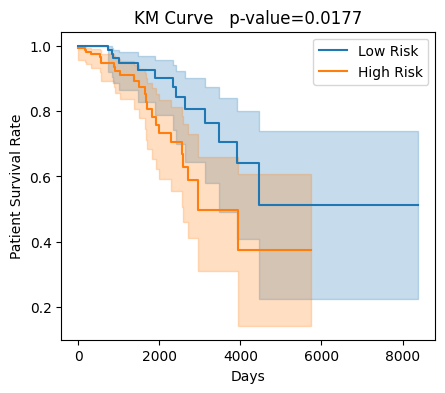

In [129]:
# draw the KM curve
# You can modify the alpha value to change the confidence interval
# The figure is not carefully designed, you can edit the color, font, etc. So that it will look better.

from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

plt.figure(figsize=(28, 4))

alpha = 0.05

kmf = KaplanMeierFitter(alpha=alpha)

ax = plt.subplot(151)
kmf.fit(all_event_times_for_test[low_risk_group], event_observed=all_death_for_test[low_risk_group], label='Low Risk')
kmf.plot(ax=ax)
kmf.fit(all_event_times_for_test[high_risk_group], event_observed=all_death_for_test[high_risk_group], label='High Risk')
kmf.plot(ax=ax)
plt.title("KM Curve"+"   "+"p-value="+str(p_value))
plt.xlabel("Days")
plt.ylabel("Patient Survival Rate")

If you check the KM curve, you will find out that if we exclude a few samples that lived a very long time, the margin between the two lines will be more obvious.

When you are preparing the figures for your paper, you can consider excluder these outliers in your figure.